# Keras Neural Network Pipeline For Monthly Equities Returns

This notebook builds a time-aware feed-forward neural network in R with `keras` to predict `R1M_Usd`, the one-month forward return.

The workflow is deliberately designed to avoid look-ahead bias:

1. Split the raw panel into a strict training sample and a strict holdout sample, with all observations on or after **2014-01-15** reserved for holdout.
2. Inside the pre-2014 training sample, create **5-year rolling training windows** and **retrain yearly** on the previous 5 years of data.
3. Use a **small hyperparameter grid** on a subset of pre-holdout rolling windows for model selection.
4. Within each training window, use the **last year as a validation slice** for early stopping, then refit on the full 5-year window before scoring the next year.
5. Refit the final model on the **last 5 pre-holdout years (2009-2013)** and score the untouched holdout set.

This setup keeps the holdout clean and ensures every prediction is generated using only information that was available at the time.


## Environment Note

Because `keras` in R relies on a Python TensorFlow backend, this notebook expects `KERAS_PYTHON` (or the fallback Python path selected below) to point to a Python environment that already has `tensorflow` installed.

On Apple Silicon, that usually means a dedicated Python environment for TensorFlow rather than the system default interpreter.


In [54]:
# Default python path to use. If this doesn't work, falls back to system python installation.
PYTHON_PATH = "/Users/hughjiang/.pyenv/versions/cs489/bin/python"

# Load packages and configure reticulate before the first Keras call.
required_packages <- c("tidyverse", "lubridate", "keras", "tensorflow", "reticulate")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]

if (length(missing_packages) > 0) {
  stop(
    "Install the missing packages before running this notebook: ",
    paste(missing_packages, collapse = ", ")
  )
}

invisible(lapply(required_packages, library, character.only = TRUE))

# Point reticulate and Python-adjacent caches at writable temp directories.
reticulate_cache_dir <- file.path(tempdir(), "reticulate-uv-cache")
matplotlib_cache_dir <- file.path(tempdir(), "matplotlib-cache")
xdg_cache_dir <- file.path(tempdir(), "xdg-cache")
dir.create(reticulate_cache_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(matplotlib_cache_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(xdg_cache_dir, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(
  RETICULATE_UV_CACHE_DIR = reticulate_cache_dir,
  UV_CACHE_DIR = reticulate_cache_dir,
  MPLCONFIGDIR = matplotlib_cache_dir,
  XDG_CACHE_HOME = xdg_cache_dir
)

# Prefer an explicit user override, then fall back to a known local Python on this machine.
python_candidates <- c(
  Sys.getenv("KERAS_PYTHON", unset = ""),
  PYTHON_PATH,
  "/Users/hughjiang/.pyenv/versions/3.11.14/bin/python",
  Sys.which("python3"),
  Sys.which("python")
)
python_candidates <- unique(python_candidates[nzchar(python_candidates)])
python_candidates <- python_candidates[file.exists(python_candidates)]

if (length(python_candidates) == 0) {
  stop("No Python interpreter was found. Set KERAS_PYTHON to a Python environment with TensorFlow installed.")
}

keras_python <- python_candidates[[1]]
Sys.setenv(RETICULATE_PYTHON = keras_python)
reticulate::use_python(keras_python, required = FALSE)

# The installed R package is the legacy keras wrapper, so request legacy mode when available.
if ("py_require_legacy_keras" %in% getNamespaceExports("keras")) {
  keras::py_require_legacy_keras()
}

if (!reticulate::py_module_available("tensorflow")) {
  stop(
    paste0(
      "TensorFlow is not available in ", keras_python, ". ",
      "Install tensorflow in that Python environment or set KERAS_PYTHON to a different one."
    )
  )
}

# Force a UTF-8 locale when possible so IRkernel can safely render notebook output.
locale_candidates <- c("en_US.UTF-8", "C.UTF-8", "UTF-8")
for (locale_name in locale_candidates) {
  locale_result <- tryCatch(
    suppressWarnings(Sys.setlocale("LC_CTYPE", locale_name)),
    error = function(...) NA_character_
  )
  if (!is.na(locale_result) && nzchar(locale_result)) {
    break
  }
}
options(encoding = "UTF-8")

# Reproducibility matters when comparing model configurations.
set.seed(423)
tensorflow::set_random_seed(423L)
options(dplyr.summarise.inform = FALSE)

# Print Python config as sanitized UTF-8 text rather than returning the raw object to the notebook renderer.
py_config_lines <- capture.output(print(reticulate::py_config()))
py_config_lines <- iconv(py_config_lines, from = "", to = "UTF-8", sub = "byte")
cat(paste(py_config_lines, collapse = "
"), "
")


python:         /Users/hughjiang/.pyenv/versions/3.11.14/envs/cs489/bin/python
libpython:      /Users/hughjiang/.pyenv/versions/3.11.14/lib/libpython3.11.dylib
pythonhome:     /Users/hughjiang/.pyenv/versions/3.11.14/envs/cs489:/Users/hughjiang/.pyenv/versions/3.11.14/envs/cs489
version:        3.11.14 (main, Feb 24 2026, 11:56:36) [Clang 17.0.0 (clang-1700.0.13.5)]
numpy:          /Users/hughjiang/.pyenv/versions/3.11.14/envs/cs489/lib/python3.11/site-packages/numpy
numpy_version:  2.4.2
tensorflow:     /Users/hughjiang/.pyenv/versions/3.11.14/envs/cs489/lib/python3.11/site-packages/tensorflow

NOTE: Python version was forced by RETICULATE_PYTHON 


## Configuration Constants

In [ ]:
# Configuration constants used throughout the notebook.
DATA_PATH <- "data_ml.RData"
HOLDOUT_START <- as.Date("2014-01-15")
TARGET_COL <- "R1M_Usd"
TRAIN_LOOKBACK_YEARS <- 5L
DATA_START_DATE <- as.Date("1999-12-31")
DATA_END_DATE <- as.Date("2019-01-01")
# Features to use
FEATURE_COL_START <- 3L
FEATURE_COL_END <- 95L
FEATURE_COL_INDICES <- FEATURE_COL_START:FEATURE_COL_END
# Which score years to use for hyperparameter tuning. For example, if we do 2011:2013 we 
#  train models to predict 2011, 2012, and 2013 with the 5 year lookback, and pick the
#  model that performed the best in all years.
TUNING_SCORE_YEARS <- 2005:2010

# DON'T NEED TO CHANGE THESE:
FINAL_HOLDOUT_SEED_OFFSET <- 999L
# First year where we have predictions. (2005)
DEVELOPMENT_START_YEAR <- lubridate::year(DATA_START_DATE) + TRAIN_LOOKBACK_YEARS + 1L


## Load Data

In [93]:
# Load the monthly equity panel and apply the same date filter used in the Section 6 starter code.
load(DATA_PATH)

FEATURE_COLS <- names(data_ml)[FEATURE_COL_INDICES]

data_ml <- data_ml %>%
  mutate(date = as.Date(date)) %>%
  filter(
    date > DATA_START_DATE,
    date < DATA_END_DATE
  ) %>%
  arrange(date, stock_id)

training_sample <- data_ml %>% filter(date < HOLDOUT_START)
holdout_sample <- data_ml %>% filter(date >= HOLDOUT_START)

split_summary <- tibble(
  sample = c("training", "holdout"),
  start_date = c(min(training_sample$date), min(holdout_sample$date)),
  end_date = c(max(training_sample$date), max(holdout_sample$date)),
  rows = c(nrow(training_sample), nrow(holdout_sample)),
  distinct_months = c(n_distinct(training_sample$date), n_distinct(holdout_sample$date))
)

split_summary


sample,start_date,end_date,rows,distinct_months
<chr>,<date>,<date>,<int>,<int>
training,2000-01-31,2013-12-31,198128,168
holdout,2014-01-31,2018-12-31,70208,60


## Helper Functions

The helpers below do five things:

- print progress logs during tuning and training;
- pass the already-uniformized features directly into the network;
- define yearly rolling windows without leaking future observations;
- build a small `keras` multilayer perceptron; and
- fit each rolling model with an internal validation slice for early stopping.


In [94]:
# Small logger so long notebook runs show useful progress updates.
log_progress <- function(...) {
  timestamp <- format(Sys.time(), "%Y-%m-%d %H:%M:%S")
  cat(sprintf("[%s] %s
", timestamp, paste(..., collapse = "")))
  flush.console()
}

# Safe correlation helper for months where one vector could have zero variance.
safe_cor <- function(x, y, method = "pearson") {
  if (length(x) < 2 || sd(x) == 0 || sd(y) == 0) {
    return(NA_real_)
  }

  cor(x, y, method = method)
}

# The features are already uniformized within each date, so we feed them directly to the network.
features_to_matrix <- function(df, feature_cols) {
  df %>%
    dplyr::select(all_of(feature_cols)) %>%
    as.matrix()
}

# Convert R matrices and vectors into TensorFlow tensors with a consistent dtype.
to_float_tensor <- function(x) {
  tensorflow::tf$convert_to_tensor(x, dtype = "float32")
}

# Reserve the last calendar year in each 5-year window for time-aware validation.
split_train_validation <- function(train_df) {
  validation_start <- lubridate::floor_date(max(train_df$date), unit = "year")

  train_core <- train_df %>% filter(date < validation_start)
  validation <- train_df %>% filter(date >= validation_start)

  if (nrow(train_core) == 0 || nrow(validation) == 0) {
    stop("Training window could not be split into train and validation slices.")
  }

  list(train_core = train_core, validation = validation)
}

# A rolling window always trains on the previous 5 calendar years and scores the next calendar year.
make_rolling_windows <- function(score_years) {
  tibble(score_year = score_years) %>%
    mutate(
      train_start = as.Date(sprintf("%d-01-01", score_year - TRAIN_LOOKBACK_YEARS)),
      train_end = as.Date(sprintf("%d-12-31", score_year - 1L)),
      score_start = as.Date(sprintf("%d-01-01", score_year)),
      score_end = as.Date(sprintf("%d-12-31", score_year))
    )
}

# Define a compact, readable multilayer perceptron for return regression.
build_model <- function(input_dim,
                        hidden_units = c(64L, 32L),
                        dropout_rate = 0.10,
                        learning_rate = 1e-3,
                        lr_decay_rate = 0.98,
                        lr_decay_steps = 250L,
                        l2_penalty = 1e-4) {
  tf <- tensorflow::tf
  hidden_units <- as.integer(hidden_units)
  keras::k_clear_session()

  l2_regularizer <- tf$keras$regularizers$L2(as.numeric(l2_penalty))
  learning_rate_schedule <- tf$keras$optimizers$schedules$ExponentialDecay(
    initial_learning_rate = as.numeric(learning_rate),
    decay_steps = as.integer(lr_decay_steps),
    decay_rate = as.numeric(lr_decay_rate),
    staircase = TRUE
  )

  model <- tf$keras$Sequential()
  model$add(tf$keras$layers$Input(shape = reticulate::tuple(as.integer(input_dim))))

  for (units in hidden_units) {
    model$add(tf$keras$layers$Dense(
      units = as.integer(units),
      activation = "relu",
      kernel_regularizer = l2_regularizer
    ))
    model$add(tf$keras$layers$Dropout(rate = as.numeric(dropout_rate)))
  }

  model$add(tf$keras$layers$Dense(units = 1L, activation = "linear"))

  model$compile(
    loss = "mse",
    optimizer = tf$keras$optimizers$Adam(learning_rate = learning_rate_schedule),
    metrics = list("mean_absolute_error")
  )

  model
}

# Train on one 5-year window, select the epoch count using the last year as validation,
# then refit on the full 5-year window before scoring the following year.
fit_and_score_window <- function(train_df,
                                 score_df,
                                 feature_cols,
                                 target_col,
                                 hidden_units,
                                 dropout_rate,
                                 learning_rate,
                                 lr_decay_rate,
                                 lr_decay_steps,
                                 batch_size,
                                 epochs,
                                 l2_penalty,
                                 patience,
                                 fit_verbose = 0,
                                 seed_offset = 0L,
                                 model_label = "window") {
  stopifnot(max(train_df$date) < min(score_df$date))

  log_progress(
    sprintf(
      paste0(
        "Starting %s | train rows=%s (%s to %s) | score rows=%s (%s to %s) | ",
        paste0(
          "hidden=%s dropout=%.2f lr=%.4g decay=%.3f/%s ",
          "batch=%s epochs=%s l2=%.4g patience=%s"
        )
      ),
      model_label,
      format(nrow(train_df), big.mark = ","),
      min(train_df$date),
      max(train_df$date),
      format(nrow(score_df), big.mark = ","),
      min(score_df$date),
      max(score_df$date),
      paste(hidden_units, collapse = " -> "),
      dropout_rate,
      learning_rate,
      lr_decay_rate,
      lr_decay_steps,
      batch_size,
      epochs,
      l2_penalty,
      patience
    )
  )

  train_split <- split_train_validation(train_df)
  train_core <- train_split$train_core
  validation <- train_split$validation

  x_core <- features_to_matrix(train_core, feature_cols)
  y_core <- train_core[[target_col]]
  x_validation <- features_to_matrix(validation, feature_cols)
  y_validation <- validation[[target_col]]

  x_core_tensor <- to_float_tensor(x_core)
  y_core_tensor <- to_float_tensor(matrix(y_core, ncol = 1))
  x_validation_tensor <- to_float_tensor(x_validation)
  y_validation_tensor <- to_float_tensor(matrix(y_validation, ncol = 1))

  tensorflow::set_random_seed(as.integer(423L + seed_offset))
  selection_model <- build_model(
    input_dim = ncol(x_core),
    hidden_units = hidden_units,
    dropout_rate = dropout_rate,
    learning_rate = learning_rate,
    lr_decay_rate = lr_decay_rate,
    lr_decay_steps = lr_decay_steps,
    l2_penalty = l2_penalty
  )

  early_stopping <- tensorflow::tf$keras$callbacks$EarlyStopping(
    monitor = "val_loss",
    patience = as.integer(patience),
    restore_best_weights = TRUE,
    verbose = 0L
  )

  selection_history <- selection_model$fit(
    x = x_core_tensor,
    y = y_core_tensor,
    validation_data = list(x_validation_tensor, y_validation_tensor),
    epochs = as.integer(epochs),
    batch_size = as.integer(batch_size),
    shuffle = TRUE,
    verbose = as.integer(fit_verbose),
    callbacks = list(early_stopping)
  )

  validation_losses <- unlist(selection_history$history[["val_loss"]])
  best_epoch <- which.min(validation_losses)
  if (length(best_epoch) == 0 || is.na(best_epoch)) {
    best_epoch <- as.integer(epochs)
  }
  best_val_loss <- min(validation_losses, na.rm = TRUE)

  log_progress(
    sprintf(
      "%s | early stopping selected epoch %s with validation loss %.6f",
      model_label,
      best_epoch,
      best_val_loss
    )
  )

  x_full <- features_to_matrix(train_df, feature_cols)
  y_full <- train_df[[target_col]]
  x_score <- features_to_matrix(score_df, feature_cols)

  x_full_tensor <- to_float_tensor(x_full)
  y_full_tensor <- to_float_tensor(matrix(y_full, ncol = 1))
  x_score_tensor <- to_float_tensor(x_score)

  tensorflow::set_random_seed(as.integer(423L + seed_offset))
  final_model <- build_model(
    input_dim = ncol(x_full),
    hidden_units = hidden_units,
    dropout_rate = dropout_rate,
    learning_rate = learning_rate,
    lr_decay_rate = lr_decay_rate,
    lr_decay_steps = lr_decay_steps,
    l2_penalty = l2_penalty
  )

  final_model$fit(
    x = x_full_tensor,
    y = y_full_tensor,
    epochs = as.integer(best_epoch),
    batch_size = as.integer(batch_size),
    shuffle = TRUE,
    verbose = as.integer(fit_verbose)
  )

  preds <- as.numeric(
    final_model$predict(
      x_score_tensor,
      batch_size = as.integer(batch_size),
      verbose = 0L
    )
  )

  log_progress(sprintf("Finished %s", model_label))

  preds
}

# Walk forward through a set of yearly windows.
run_walk_forward <- function(data_source,
                             windows,
                             feature_cols,
                             target_col,
                             params,
                             fit_verbose = 0,
                             run_label = "walk-forward") {
  log_progress(
    sprintf(
      "Running %s across %s yearly windows",
      run_label,
      nrow(windows)
    )
  )

  purrr::pmap_dfr(
    windows,
    function(score_year, train_start, train_end, score_start, score_end) {
      train_window <- data_source %>%
        filter(date >= train_start, date <= train_end)

      score_window <- data_source %>%
        filter(date >= score_start, date <= score_end)

      window_label <- sprintf("%s | score_year=%s", run_label, score_year)

      preds <- fit_and_score_window(
        train_df = train_window,
        score_df = score_window,
        feature_cols = feature_cols,
        target_col = target_col,
        hidden_units = params$hidden_units[[1]],
        dropout_rate = params$dropout_rate,
        learning_rate = params$learning_rate,
        lr_decay_rate = params$lr_decay_rate,
        lr_decay_steps = params$lr_decay_steps,
        batch_size = params$batch_size,
        epochs = params$epochs,
        l2_penalty = params$l2_penalty,
        patience = params$patience,
        fit_verbose = fit_verbose,
        seed_offset = score_year,
        model_label = window_label
      )

      window_rank_ic <- safe_cor(preds, score_window[[target_col]], method = "spearman")
      window_hit_ratio <- mean(preds * score_window[[target_col]] > 0)

      log_progress(
        sprintf(
          "Completed %s | rank IC=%.4f | hit ratio=%.4f",
          window_label,
          window_rank_ic,
          window_hit_ratio
        )
      )

      score_window %>%
        transmute(
          stock_id,
          date,
          actual_return = .data[[target_col]],
          predicted_return = preds,
          score_year = score_year,
          train_start = train_start,
          train_end = train_end
        )
    }
  )
}

# Summarize predictions both overall and month by month.
summarise_predictions <- function(prediction_df) {
  monthly_metrics <- prediction_df %>%
    group_by(date) %>%
    summarise(
      names_scored = n(),
      monthly_ic = safe_cor(predicted_return, actual_return),
      monthly_rank_ic = safe_cor(predicted_return, actual_return, method = "spearman"),
      monthly_hit_ratio = mean(predicted_return * actual_return > 0)
    )

  overall_metrics <- prediction_df %>%
    summarise(
      observations = n(),
      rmse = sqrt(mean((predicted_return - actual_return)^2)),
      mae = mean(abs(predicted_return - actual_return)),
      overall_ic = safe_cor(predicted_return, actual_return),
      overall_rank_ic = safe_cor(predicted_return, actual_return, method = "spearman"),
      hit_ratio = mean(predicted_return * actual_return > 0)
    ) %>%
    bind_cols(
      monthly_metrics %>%
        summarise(
          mean_monthly_ic = mean(monthly_ic, na.rm = TRUE),
          mean_monthly_rank_ic = mean(monthly_rank_ic, na.rm = TRUE),
          mean_monthly_hit_ratio = mean(monthly_hit_ratio, na.rm = TRUE)
        )
    )

  list(overall = overall_metrics, monthly = monthly_metrics)
}


## Rolling Windows Inside The Training Sample

Because everything from **2014-01-15 onward** is a strict holdout set, the yearly rolling retraining is done **only inside the pre-2014 training sample**.

That gives us a realistic development workflow:

- train on years `t-5` through `t-1`;
- score year `t`;
- roll forward by one year and repeat.


In [95]:
training_years <- sort(unique(lubridate::year(training_sample$date)))
development_windows <- make_rolling_windows(score_years = training_years[training_years >= DEVELOPMENT_START_YEAR])

# Use only the last few pre-holdout windows for a lightweight hyperparameter search.
tuning_windows <- development_windows %>% filter(score_year %in% TUNING_SCORE_YEARS)

development_windows


score_year,train_start,train_end,score_start,score_end
<dbl>,<date>,<date>,<date>,<date>
2005,2000-01-01,2004-12-31,2005-01-01,2005-12-31
2006,2001-01-01,2005-12-31,2006-01-01,2006-12-31
2007,2002-01-01,2006-12-31,2007-01-01,2007-12-31
2008,2003-01-01,2007-12-31,2008-01-01,2008-12-31
2009,2004-01-01,2008-12-31,2009-01-01,2009-12-31
2010,2005-01-01,2009-12-31,2010-01-01,2010-12-31
2011,2006-01-01,2010-12-31,2011-01-01,2011-12-31
2012,2007-01-01,2011-12-31,2012-01-01,2012-12-31
2013,2008-01-01,2012-12-31,2013-01-01,2013-12-31


In [96]:
tuning_windows

score_year,train_start,train_end,score_start,score_end
<dbl>,<date>,<date>,<date>,<date>
2005,2000-01-01,2004-12-31,2005-01-01,2005-12-31
2006,2001-01-01,2005-12-31,2006-01-01,2006-12-31
2007,2002-01-01,2006-12-31,2007-01-01,2007-12-31
2008,2003-01-01,2007-12-31,2008-01-01,2008-12-31
2009,2004-01-01,2008-12-31,2009-01-01,2009-12-31
2010,2005-01-01,2009-12-31,2010-01-01,2010-12-31


## Basic Hyperparameter Tuning

**NOTE**: We can skip this now that we've already run it once and selected the model

The tuning set below focuses on a **small number of architecture families** and more variation in the optimization and regularization settings that usually matter most for noisy stock-return prediction tasks.

The candidate set includes:

- **single hidden layer** models, which are often competitive on tabular cross-sectional equity data;
- a compact **two hidden layer** model for slightly richer nonlinear interactions; and
- more tuning around **learning rate, learning-rate decay, dropout, L2 regularization, batch size, and early stopping patience**.

Candidates are ranked by **average monthly rank IC** on the pre-holdout tuning windows.


In [97]:
architecture_grid <- tibble(
  architecture_id = c("single_64" , "single_128", "double_64_32"),
  hidden_units = list(c(64L) , c(128L), c(64L, 32L))
)

regularization_grid <- tibble(
  profile_id = c(
    "balanced",
    "conservative_regularized",
    "fast_decay",
    "small_step_strong_l2"
  ),
  dropout_rate = c(0.10, 0.20, 0.10, 0.05),
  learning_rate = c(1e-3, 5e-4, 2e-3, 3e-4),
  lr_decay_rate = c(0.985, 0.990, 0.960, 0.995),
  lr_decay_steps = c(250L, 300L, 175L, 350L),
  batch_size = c(2048L, 2048L, 1024L, 2048L),
  epochs = c(25L, 30L, 20L, 35L),
  l2_penalty = c(1e-4, 5e-4, 1e-4, 1e-3),
  patience = c(4L, 5L, 4L, 5L)
)

tuning_grid <- tidyr::crossing(architecture_grid, regularization_grid) %>%
  mutate(model_id = row_number()) %>%
  select(
    model_id,
    architecture_id,
    profile_id,
    hidden_units,
    dropout_rate,
    learning_rate,
    lr_decay_rate,
    lr_decay_steps,
    batch_size,
    epochs,
    l2_penalty,
    patience
  )

log_progress("Starting hyperparameter tuning on the selected pre-holdout windows.")

tuning_results <- purrr::pmap_dfr(
  tuning_grid,
  function(model_id,
           architecture_id,
           profile_id,
           hidden_units,
           dropout_rate,
           learning_rate,
           lr_decay_rate,
           lr_decay_steps,
           batch_size,
           epochs,
           l2_penalty,
           patience) {
    params <- tibble(
      hidden_units = list(hidden_units),
      dropout_rate = dropout_rate,
      learning_rate = learning_rate,
      lr_decay_rate = lr_decay_rate,
      lr_decay_steps = lr_decay_steps,
      batch_size = batch_size,
      epochs = epochs,
      l2_penalty = l2_penalty,
      patience = patience
    )

    log_progress(
      sprintf(
        paste0(
          "Evaluating tuning candidate %s/%s | arch=%s | profile=%s | hidden=%s ",
          "dropout=%.2f lr=%.4g decay=%.3f/%s batch=%s epochs=%s l2=%.4g patience=%s"
        ),
        model_id,
        nrow(tuning_grid),
        architecture_id,
        profile_id,
        paste(hidden_units, collapse = " -> "),
        dropout_rate,
        learning_rate,
        lr_decay_rate,
        lr_decay_steps,
        batch_size,
        epochs,
        l2_penalty,
        patience
      )
    )

    tuning_predictions <- run_walk_forward(
      data_source = training_sample,
      windows = tuning_windows,
      feature_cols = FEATURE_COLS,
      target_col = TARGET_COL,
      params = params,
      fit_verbose = 0,
      run_label = sprintf("tuning candidate %s", model_id)
    )

    tuning_summary <- summarise_predictions(tuning_predictions)

    log_progress(
      sprintf(
        paste0(
          "Finished tuning candidate %s | mean monthly rank IC=%.4f | ",
          "RMSE=%.4f | hit ratio=%.4f"
        ),
        model_id,
        tuning_summary$overall$mean_monthly_rank_ic[[1]],
        tuning_summary$overall$rmse[[1]],
        tuning_summary$overall$hit_ratio[[1]]
      )
    )

    tuning_summary$overall %>%
      mutate(
        model_id = model_id,
        architecture_id = architecture_id,
        profile_id = profile_id,
        hidden_units = paste(hidden_units, collapse = " -> "),
        dropout_rate = dropout_rate,
        learning_rate = learning_rate,
        lr_decay_rate = lr_decay_rate,
        lr_decay_steps = lr_decay_steps,
        batch_size = batch_size,
        epochs = epochs,
        l2_penalty = l2_penalty,
        patience = patience
      ) %>%
      select(
        model_id,
        architecture_id,
        profile_id,
        hidden_units,
        dropout_rate,
        learning_rate,
        lr_decay_rate,
        lr_decay_steps,
        batch_size,
        epochs,
        l2_penalty,
        patience,
        everything()
      )
  }
) %>%
  arrange(desc(mean_monthly_rank_ic), rmse)

log_progress("Completed hyperparameter tuning.")

tuning_results


[2026-04-12 13:41:42] Starting hyperparameter tuning on the selected pre-holdout windows.


[2026-04-12 13:41:42] Evaluating tuning candidate 1/12 | arch=double_64_32 | profile=balanced | hidden=64 -> 32 dropout=0.10 lr=0.001 decay=0.985/250 batch=2048 epochs=25 l2=0.0001 patience=4
[2026-04-12 13:41:42] Running tuning candidate 1 across 6 yearly windows
[2026-04-12 13:41:42] Starting tuning candidate 1 | score_year=2005 | train rows=69,248 (2000-01-31 to 2004-12-31) | score rows=14,332 (2005-01-31 to 2005-12-31) | hidden=64 -> 32 dropout=0.10 lr=0.001 decay=0.985/250 batch=2048 epochs=25 l2=0.0001 patience=4
[2026-04-12 13:41:46] tuning candidate 1 | score_year=2005 | early stopping selected epoch 25 with validation loss 0.014945
[2026-04-12 13:41:49] Finished tuning candidate 1 | score_year=2005
[2026-04-12 13:41:49] Completed tuning candidate 1 | score_year=2005 | rank IC=0.0579 | hit ratio=0.5916
[2026-04-12 13:41:49] Starting tuning candidate 1 | score_year=2006 | train rows=70,510 (2001-01-31 to 2005-12-31) | score rows=14,349 (2006-01-31 to 2006-12-31) | hidden=64 -> 3

model_id,architecture_id,profile_id,hidden_units,dropout_rate,learning_rate,lr_decay_rate,lr_decay_steps,batch_size,epochs,⋯,patience,observations,rmse,mae,overall_ic,overall_rank_ic,hit_ratio,mean_monthly_ic,mean_monthly_rank_ic,mean_monthly_hit_ratio
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,double_64_32,conservative_regularized,64 -> 32,0.20,5e-04,0.990,300,2048,30,⋯,5,85945,0.1788505,0.08528673,-0.0254645893,-0.032934560,0.5473035,0.04547113,0.029470622,0.5472610
1,double_64_32,balanced,64 -> 32,0.10,1e-03,0.985,250,2048,25,⋯,4,85945,0.1788894,0.08542151,-0.0021800001,-0.025718284,0.5412531,0.04983250,0.028172140,0.5412127
4,double_64_32,small_step_strong_l2,64 -> 32,0.05,3e-04,0.995,350,2048,35,⋯,5,85945,0.1789529,0.08545262,-0.0179686530,-0.039433644,0.5397638,0.04091704,0.025076146,0.5397228
3,double_64_32,fast_decay,64 -> 32,0.10,2e-03,0.960,175,1024,20,⋯,4,85945,0.1790018,0.08555488,-0.0033113190,-0.036854077,0.5405434,0.04897571,0.024584128,0.5404993
11,single_64,fast_decay,64,0.10,2e-03,0.960,175,1024,20,⋯,4,85945,0.1794489,0.08614606,-0.0014158221,-0.026388371,0.5298738,0.02971326,0.018378951,0.5298373
8,single_128,small_step_strong_l2,128,0.05,3e-04,0.995,350,2048,35,⋯,5,85945,0.1806315,0.08843688,0.0074207915,0.008351579,0.5168887,0.02578105,0.015169551,0.5168810
6,single_128,conservative_regularized,128,0.20,5e-04,0.990,300,2048,30,⋯,5,85945,0.1794011,0.08620849,0.0005358024,-0.014070885,0.5280470,0.02863261,0.014293802,0.5280198
9,single_64,balanced,64,0.10,1e-03,0.985,250,2048,25,⋯,4,85945,0.1801539,0.08732713,-0.0079655352,-0.026497325,0.5116644,0.02544398,0.013276626,0.5116392
7,single_128,fast_decay,128,0.10,2e-03,0.960,175,1024,20,⋯,4,85945,0.1795910,0.08620275,-0.0068850070,-0.015384309,0.5275351,0.02589021,0.012721406,0.5275000


In [98]:
tuning_results

model_id,architecture_id,profile_id,hidden_units,dropout_rate,learning_rate,lr_decay_rate,lr_decay_steps,batch_size,epochs,⋯,patience,observations,rmse,mae,overall_ic,overall_rank_ic,hit_ratio,mean_monthly_ic,mean_monthly_rank_ic,mean_monthly_hit_ratio
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,double_64_32,conservative_regularized,64 -> 32,0.20,5e-04,0.990,300,2048,30,⋯,5,85945,0.1788505,0.08528673,-0.0254645893,-0.032934560,0.5473035,0.04547113,0.029470622,0.5472610
1,double_64_32,balanced,64 -> 32,0.10,1e-03,0.985,250,2048,25,⋯,4,85945,0.1788894,0.08542151,-0.0021800001,-0.025718284,0.5412531,0.04983250,0.028172140,0.5412127
4,double_64_32,small_step_strong_l2,64 -> 32,0.05,3e-04,0.995,350,2048,35,⋯,5,85945,0.1789529,0.08545262,-0.0179686530,-0.039433644,0.5397638,0.04091704,0.025076146,0.5397228
3,double_64_32,fast_decay,64 -> 32,0.10,2e-03,0.960,175,1024,20,⋯,4,85945,0.1790018,0.08555488,-0.0033113190,-0.036854077,0.5405434,0.04897571,0.024584128,0.5404993
11,single_64,fast_decay,64,0.10,2e-03,0.960,175,1024,20,⋯,4,85945,0.1794489,0.08614606,-0.0014158221,-0.026388371,0.5298738,0.02971326,0.018378951,0.5298373
8,single_128,small_step_strong_l2,128,0.05,3e-04,0.995,350,2048,35,⋯,5,85945,0.1806315,0.08843688,0.0074207915,0.008351579,0.5168887,0.02578105,0.015169551,0.5168810
6,single_128,conservative_regularized,128,0.20,5e-04,0.990,300,2048,30,⋯,5,85945,0.1794011,0.08620849,0.0005358024,-0.014070885,0.5280470,0.02863261,0.014293802,0.5280198
9,single_64,balanced,64,0.10,1e-03,0.985,250,2048,25,⋯,4,85945,0.1801539,0.08732713,-0.0079655352,-0.026497325,0.5116644,0.02544398,0.013276626,0.5116392
7,single_128,fast_decay,128,0.10,2e-03,0.960,175,1024,20,⋯,4,85945,0.1795910,0.08620275,-0.0068850070,-0.015384309,0.5275351,0.02589021,0.012721406,0.5275000


In [99]:
selected_config <- tuning_grid %>%
  filter(model_id == tuning_results$model_id[[1]])

selected_config


model_id,architecture_id,profile_id,hidden_units,dropout_rate,learning_rate,lr_decay_rate,lr_decay_steps,batch_size,epochs,l2_penalty,patience
<int>,<chr>,<chr>,<list>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>
2,double_64_32,conservative_regularized,64,0.2,5e-04,0.99,300,2048,30,5e-04,5
2,double_64_32,conservative_regularized,32,0.2,5e-04,0.99,300,2048,30,5e-04,5


In [113]:
MODEL_CONFIG_PATH <- "selected_model_config.rds"

In [114]:
# Save config
saveRDS(selected_config, MODEL_CONFIG_PATH)

In [116]:
# Load config
selected_config <- readRDS(MODEL_CONFIG_PATH)
selected_config

model_id,architecture_id,profile_id,hidden_units,dropout_rate,learning_rate,lr_decay_rate,lr_decay_steps,batch_size,epochs,l2_penalty,patience
<int>,<chr>,<chr>,<list>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>
2,double_64_32,conservative_regularized,64,0.2,5e-04,0.99,300,2048,30,5e-04,5
2,double_64_32,conservative_regularized,32,0.2,5e-04,0.99,300,2048,30,5e-04,5


## Full Pre-Holdout Walk-Forward Backtest

Once the small tuning exercise picks a configuration, rerun the yearly 5-year rolling backtest across **all available pre-holdout windows**. This gives a cleaner view of how the chosen setup behaved before 2014.


In [100]:
log_progress("Running the full pre-holdout walk-forward backtest with the selected configuration.")

development_predictions <- run_walk_forward(
  data_source = training_sample,
  windows = development_windows,
  feature_cols = FEATURE_COLS,
  target_col = TARGET_COL,
  params = selected_config,
  fit_verbose = 0,
  run_label = "development backtest"
)

development_summary <- summarise_predictions(development_predictions)

log_progress("Completed the full pre-holdout walk-forward backtest.")

development_summary$overall


[2026-04-12 13:48:51] Running the full pre-holdout walk-forward backtest with the selected configuration.
[2026-04-12 13:48:51] Running development backtest across 9 yearly windows
[2026-04-12 13:48:51] Starting development backtest | score_year=2005 | train rows=69,248 (2000-01-31 to 2004-12-31) | score rows=14,332 (2005-01-31 to 2005-12-31) | hidden=64 -> 32 dropout=0.20 lr=0.0005 decay=0.990/300 batch=2048 epochs=30 l2=0.0005 patience=5
[2026-04-12 13:48:54] development backtest | score_year=2005 | early stopping selected epoch 30 with validation loss 0.024694
[2026-04-12 13:48:57] Finished development backtest | score_year=2005
[2026-04-12 13:48:57] Completed development backtest | score_year=2005 | rank IC=0.0572 | hit ratio=0.5914
[2026-04-12 13:48:57] Starting development backtest | score_year=2006 | train rows=70,510 (2001-01-31 to 2005-12-31) | score rows=14,349 (2006-01-31 to 2006-12-31) | hidden=64 -> 32 dropout=0.20 lr=0.0005 decay=0.990/300 batch=2048 epochs=30 l2=0.0005 p

observations,rmse,mae,overall_ic,overall_rank_ic,hit_ratio,mean_monthly_ic,mean_monthly_rank_ic,mean_monthly_hit_ratio
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
128880,0.1667554,0.07888414,-0.01812713,-0.04129018,0.5556952,0.04056578,0.01998542,0.5556629


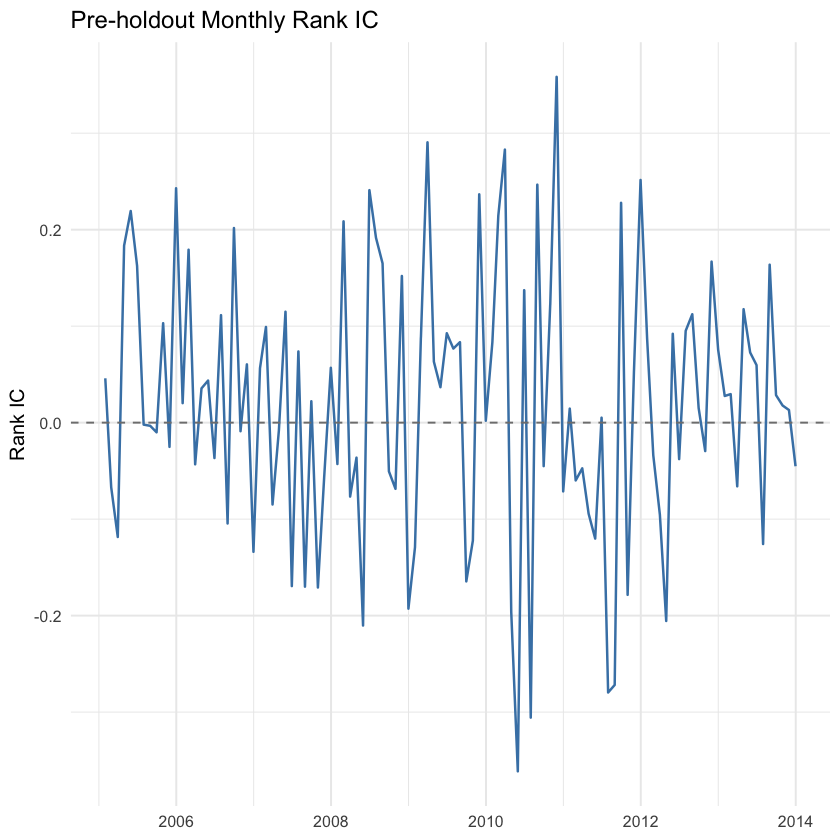

In [101]:
ggplot(development_summary$monthly, aes(x = date, y = monthly_rank_ic)) +
  geom_line(color = "steelblue", linewidth = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  labs(
    title = "Pre-holdout Monthly Rank IC",
    x = NULL,
    y = "Rank IC"
  ) +
  theme_minimal(base_size = 12)


## Final Holdout Evaluation

The holdout period is never used for model selection. After tuning is complete, train one final model on the **last 5 pre-holdout years (2009-2013)** and score the untouched holdout sample.


In [102]:
log_progress("Training the final pre-holdout model and scoring the strict holdout sample.")

final_train_start <- as.Date(sprintf("%d-01-01", lubridate::year(HOLDOUT_START) - TRAIN_LOOKBACK_YEARS))
final_train_end <- as.Date(sprintf("%d-12-31", lubridate::year(HOLDOUT_START) - 1L))

final_train_window <- training_sample %>%
  filter(date >= final_train_start, date <= final_train_end)

log_progress(paste0("Final train window: ", final_train_start, " to ", final_train_end))

holdout_predictions <- holdout_sample %>%
  mutate(
    predicted_return = fit_and_score_window(
      train_df = final_train_window,
      score_df = holdout_sample,
      feature_cols = FEATURE_COLS,
      target_col = TARGET_COL,
      hidden_units = selected_config$hidden_units[[1]],
      dropout_rate = selected_config$dropout_rate,
      learning_rate = selected_config$learning_rate,
      lr_decay_rate = selected_config$lr_decay_rate,
      lr_decay_steps = selected_config$lr_decay_steps,
      batch_size = selected_config$batch_size,
      epochs = selected_config$epochs,
      l2_penalty = selected_config$l2_penalty,
      patience = selected_config$patience,
      fit_verbose = 0,
      seed_offset = FINAL_HOLDOUT_SEED_OFFSET,
      model_label = "final holdout model"
    )
  ) %>%
  transmute(
    stock_id,
    date,
    actual_return = .data[[TARGET_COL]],
    predicted_return
  )

holdout_summary <- summarise_predictions(holdout_predictions)

log_progress("Completed holdout scoring.")

holdout_summary$overall


[2026-04-12 13:49:50] Training the final pre-holdout model and scoring the strict holdout sample.
[2026-04-12 13:49:50] Final train window: 2009-01-01 to 2013-12-31
[2026-04-12 13:49:50] Starting final holdout model | train rows=71,572 (2009-01-31 to 2013-12-31) | score rows=70,208 (2014-01-31 to 2018-12-31) | hidden=64 -> 32 dropout=0.20 lr=0.0005 decay=0.990/300 batch=2048 epochs=30 l2=0.0005 patience=5
[2026-04-12 13:49:54] final holdout model | early stopping selected epoch 30 with validation loss 0.028157
[2026-04-12 13:49:57] Finished final holdout model
[2026-04-12 13:49:57] Completed holdout scoring.


observations,rmse,mae,overall_ic,overall_rank_ic,hit_ratio,mean_monthly_ic,mean_monthly_rank_ic,mean_monthly_hit_ratio
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
70208,0.19263,0.06727684,0.02881154,-0.01245879,0.5460346,0.02282533,-0.01491838,0.5467687


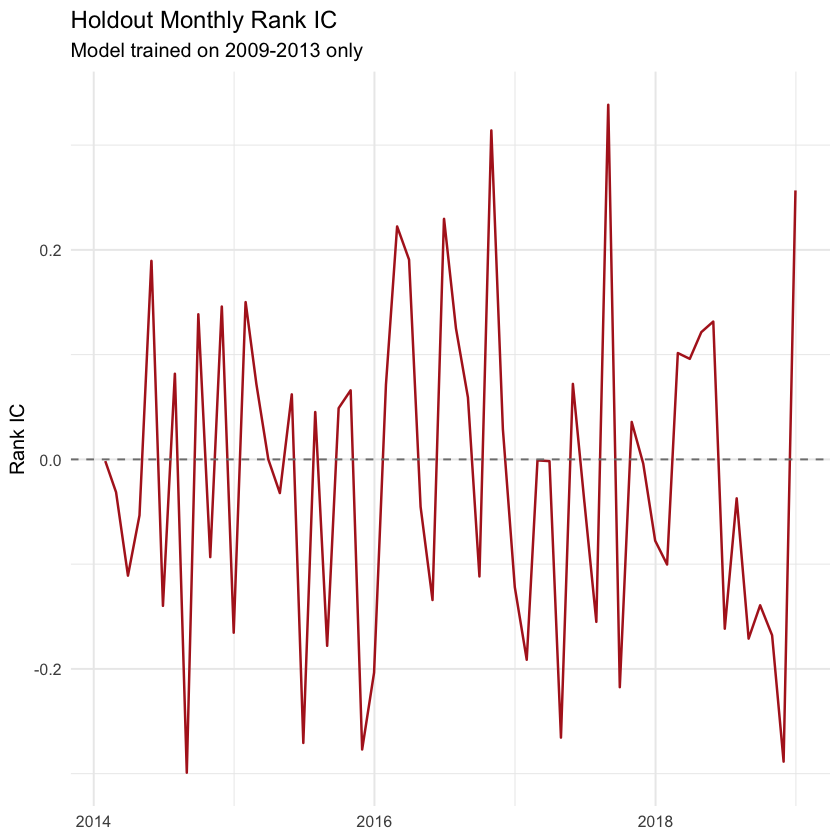

In [103]:
ggplot(holdout_summary$monthly, aes(x = date, y = monthly_rank_ic)) +
  geom_line(color = "firebrick", linewidth = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  labs(
    title = "Holdout Monthly Rank IC",
    subtitle = "Model trained on 2009-2013 only",
    x = NULL,
    y = "Rank IC"
  ) +
  theme_minimal(base_size = 12)


In [108]:
holdout_summary

$overall
# A tibble: 1 × 9
  observations  rmse    mae overall_ic overall_rank_ic hit_ratio mean_monthly_ic
         <int> <dbl>  <dbl>      <dbl>           <dbl>     <dbl>           <dbl>
1        70208 0.193 0.0673     0.0288         -0.0125     0.546          0.0228
# ℹ 2 more variables: mean_monthly_rank_ic <dbl>, mean_monthly_hit_ratio <dbl>

$monthly
# A tibble: 60 × 5
   date       names_scored monthly_ic monthly_rank_ic monthly_hit_ratio
   <date>            <int>      <dbl>           <dbl>             <dbl>
 1 2014-01-31         1192     0.0646        -0.00158             0.745
 2 2014-02-28         1192    -0.0268        -0.0313              0.589
 3 2014-03-31         1192    -0.0239        -0.111               0.485
 4 2014-04-30         1193    -0.0199        -0.0535              0.631
 5 2014-05-31         1193     0.180          0.190               0.779
 6 2014-06-30         1193    -0.0791        -0.140               0.220
 7 2014-07-31         1193     0.120          0.0818              0.867
 8 2014-08-31         1193    -0.234         -0.299               0.182
 9 2014-09-30         1192     0.0464         0.139               0.802
10 2014-10-31         1192     0.0682        -0.0933              0.694
# ℹ 50 more rows

Get final predictions for entire dataset

In [110]:
all_predictions <- bind_rows(
  development_predictions %>%
    transmute(
      stock_id,
      date,
      actual_return,
      predicted_return,
      sample = "in_sample"
    ),
  holdout_predictions %>%
    transmute(
      stock_id,
      date,
      actual_return,
      predicted_return,
      sample = "holdout"
    )
) %>%
  arrange(date, stock_id)

In [111]:
all_predictions

stock_id,date,actual_return,predicted_return,sample
<int>,<date>,<dbl>,<dbl>,<chr>
1,2005-01-31,0.111,0.01747690,in_sample
2,2005-01-31,-0.015,0.02124324,in_sample
3,2005-01-31,-0.029,0.02096656,in_sample
4,2005-01-31,0.091,0.01811518,in_sample
5,2005-01-31,0.041,0.01114800,in_sample
6,2005-01-31,0.057,0.01606138,in_sample
7,2005-01-31,0.020,0.02161847,in_sample
8,2005-01-31,-0.005,0.01353580,in_sample
9,2005-01-31,0.017,0.02431957,in_sample


In [119]:
saveRDS(all_predictions, "preds/nn_preds.rds")

## Notes

- The features are already uniformized within each date, so the notebook does not apply an additional rolling-window z-score transform.
- The yearly walk-forward loop uses only prior data, so there is no contamination from future returns.
- The holdout set stays untouched until the very end, which makes it suitable for a final out-of-sample check.
- The Keras backend must be configured before the first model build. If the setup cell stops early, point `KERAS_PYTHON` at a Python environment that already has TensorFlow installed.
